In [438]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc,colors
import os
from salishsea_tools import visualisations as vis
import netCDF4 as nc
import pandas as pd

In [439]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [440]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [441]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])

In [442]:
path_run = '/data/jvalenti/results/' 
start = datetime(2024,1,1)

hbac = xr.open_dataset(path_run+make_filename(path_run,start,0, var='biol_T', res='h')).heterotrophic_bacteria.isel(time_counter=0)

In [443]:
#(imin,imax,jmin,jmax)
regions = {'JdF':(25,125,250,400),'NSoG':(100,225,650,720),'CSoG':(180,300,450,550),'PS':(200,300,25,200)}
colors_reg={'JdF':'tab:blue','NSoG':'tab:orange','CSoG':'tab:green','PS':'tab:red'}
def mark_region(axs,region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    axs.plot(x, y, color=color,label=region)

In [444]:
mean_profiles = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_full_3year.npy')
time = pd.date_range(start='2023-01-01',end='2025-12-29',freq='D')
obs = pd.read_excel('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/obs_monterrey_S1.xlsx',header= [3],skiprows=[4,5])
obs['Bacteria biomass'] = obs['Bacteria']/2.5e6
obs = obs[obs['Depth']<400]
obs['Date '] = obs['Date '].astype('datetime64[ns]')

In [445]:
obs['Date '] = pd.to_datetime(obs['Date '])
obs['Day'] = obs['Date '].dt.normalize()
depth = np.array(hbac.deptht)

obs_profiles = []

for (site, day), prof in obs.groupby(['Site', 'Day']):

    prof = prof.sort_values('Depth')

    z = prof['Depth'].to_numpy()
    b = prof['Bacteria biomass'].to_numpy()

    good = np.isfinite(z) & np.isfinite(b)
    z = z[good]
    b = b[good]

    # Interpolate obs onto model depth
    interp_prof = np.interp(depth,z,b,left=np.nan,right=np.nan)
    obs_profiles.append(interp_prof)

obs_profiles = np.asarray(obs_profiles)

# Observational statistics
obs_mean = np.nanmean(obs_profiles, axis=0)
obs_min  = np.nanmin(obs_profiles, axis=0)
obs_max  = np.nanmax(obs_profiles, axis=0)

# Number of casts contributing at each depth
n_obs = np.sum(np.isfinite(obs_profiles), axis=0)

/tmp/ipykernel_3657905/354425417.py:25: RuntimeWarning: Mean of empty slice
  obs_mean = np.nanmean(obs_profiles, axis=0)
/tmp/ipykernel_3657905/354425417.py:26: RuntimeWarning: All-NaN slice encountered
  obs_min  = np.nanmin(obs_profiles, axis=0)
/tmp/ipykernel_3657905/354425417.py:27: RuntimeWarning: All-NaN slice encountered
  obs_max  = np.nanmax(obs_profiles, axis=0)


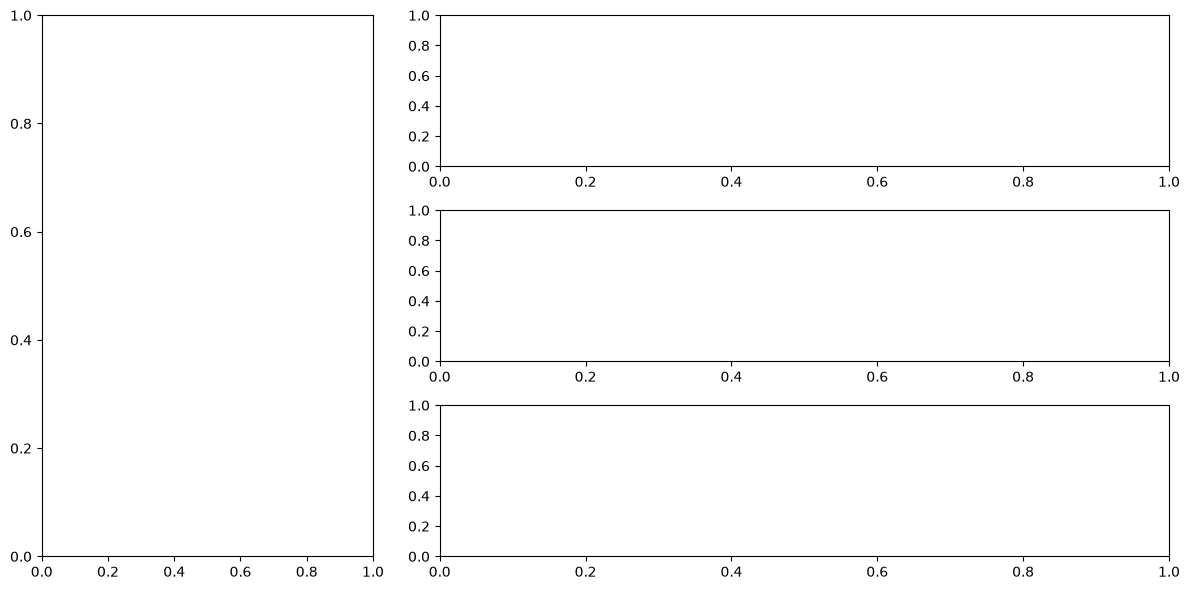

In [446]:
import matplotlib.gridspec as gridspec

colorsn=['tab:blue','tab:orange','tab:green','tab:red']

# Create a figure and a GridSpec layout
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(3, 3, height_ratios=[1, 1, 1], width_ratios=[1,1,1])

# Add the first two single large figures (one per column)
ax1 = fig.add_subplot(gs[:, 0])  # Occupies all rows in column 1

# Add the upper timeseries
ax3 = fig.add_subplot(gs[0, 1:])  # JdF & SoG
# Add the middle timeseries
ax5 = fig.add_subplot(gs[1, 1:])  # JdF & SoG
# Add the bottom timeseries
ax7 = fig.add_subplot(gs[2, 1:])  # JdF & SoG

# Adjust layout for better visualization
plt.tight_layout()
plt.show()
axes = fig.get_axes()

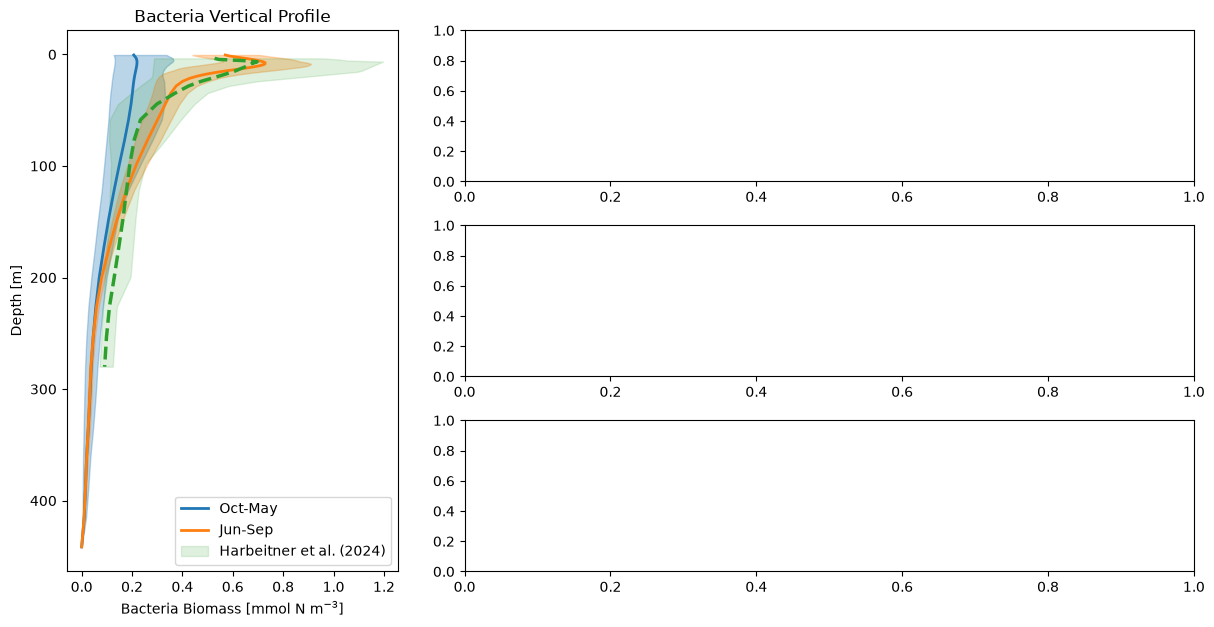

In [447]:
# June–September
summer_idx = (time.month > 5) & (time.month < 10)

summer = mean_profiles[summer_idx]
winter = mean_profiles[~summer_idx]

# Mean profiles
summer_mean = np.nanmean(summer, axis=0)
winter_mean = np.nanmean(winter, axis=0)

# 10th–90th percentiles
summer_p10 = np.nanpercentile(summer, 10, axis=0)
summer_p90 = np.nanpercentile(summer, 90, axis=0)

winter_p10 = np.nanpercentile(winter, 10, axis=0)
winter_p90 = np.nanpercentile(winter, 90, axis=0)


# Winter 
axes[0].fill_betweenx(hbac.deptht,winter_p10,winter_p90,color='tab:blue',alpha=0.3)
axes[0].plot(winter_mean,hbac.deptht,color='tab:blue',lw=2,label='Oct-May')


# Summer
axes[0].fill_betweenx(hbac.deptht,summer_p10,summer_p90,color='tab:orange',alpha=0.3)
axes[0].plot(summer_mean,hbac.deptht,color='tab:orange',lw=2,label='Jun-Sep')


axes[0].invert_yaxis()
axes[0].set_xlabel(r'Bacteria Biomass [mmol N m$^{-3}$]')
axes[0].set_ylabel('Depth [m]')
axes[0].set_title('Bacteria Vertical Profile')


# Only show depths with enough observational profiles
mask_w = n_obs >= 5

axes[0].fill_betweenx(
    depth[mask_w],
    obs_min[mask_w],
    obs_max[mask_w],
    color='tab:green',
    alpha=0.15,
    label='Harbeitner et al. (2024)'
)

axes[0].plot(
    obs_mean[mask_w],
    depth[mask_w],
    color='tab:green',
    lw=2.5,
    ls='--',
)

axes[0].legend()
fig

In [448]:
mean_profiles_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/profiles_regions_3year.npy')
vol = mask.volume.where(mask.tmask == 1).sel(t=0)
zmax = 30
Len = mean_profiles.shape[0]

weighted_means = np.full((len(regions.keys())+1,Len), np.nan)

def weighted_mean_concentration(mean_profile,region=None,regions=None,kmax=40):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        vol_r = vol.isel(y=slice(y0, y1), x=slice(x0, x1),z=slice(0,kmax))
    else:
        region = 'full domain'
        vol_r = vol.isel(z=slice(0,kmax))

    vol_r = vol_r.sum(axis=(1,2))
    weighted_mean = np.average(mean_profile[:,:kmax],axis=1,weights=vol_r)
    return weighted_mean

for ii, region in enumerate(regions.keys()):
    weighted_means[ii,:] = weighted_mean_concentration(mean_profiles_reg[ii,:,:], region=region, regions=regions,kmax = zmax)

weighted_means_full = weighted_mean_concentration(mean_profiles,kmax = zmax)

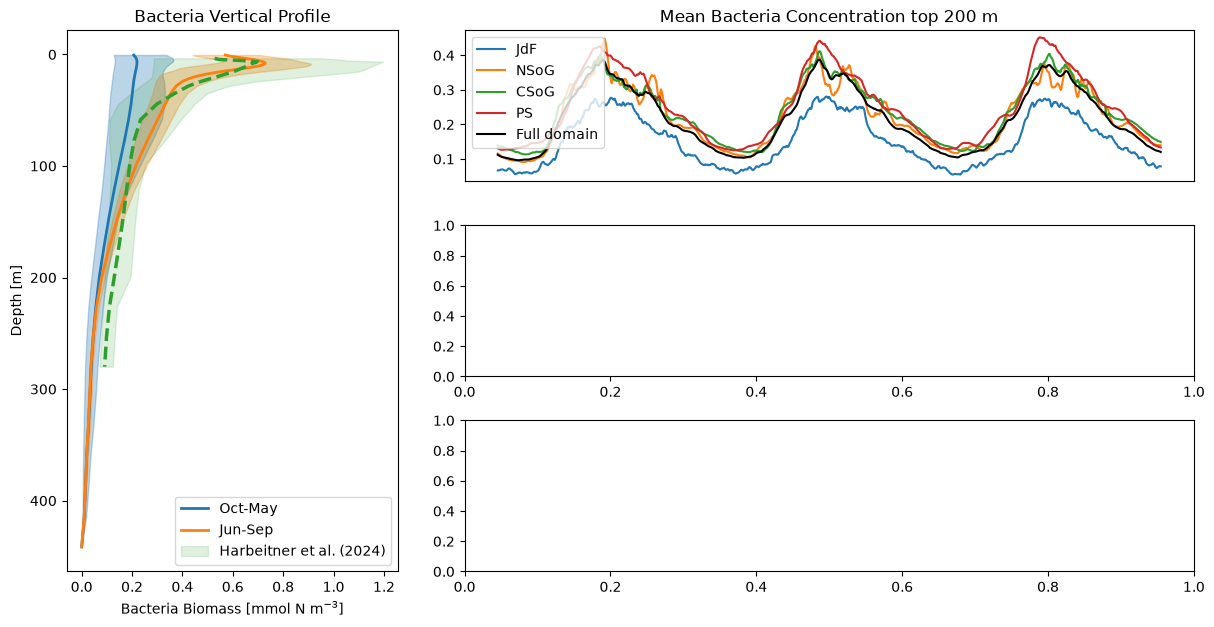

In [449]:
axes[1].clear()
for ii, region in enumerate(regions.keys()):
    axes[1].plot(time,weighted_means[ii,:].T,c=colors_reg[region],label=region)
axes[1].plot(time,weighted_means_full,c='k',label='Full domain')
axes[1].set_title('Mean Bacteria Concentration top 200 m')
#axes[1].set_ylabel('Bacteria biomass (mmol N/m3)')
#axes[1].set_ylabel(r'Bacteria Biomass [mmol N m$^{-3}$]')

axes[1].tick_params(bottom=False, labelbottom=False)
axes[1].legend()
fig

In [450]:
DM = np.argmax(mean_profiles,axis=1)
DMr = np.argmax(mean_profiles_reg,axis=2)
Dmax = np.max(mean_profiles,axis=1)
Dmaxr = np.max(mean_profiles_reg,axis=2)
deptht = mask.gdept_1d[0,:]

dtm = np.full(DM.shape,np.nan)
dtmr = np.full(DMr.shape,np.nan)

for i in range(DM.shape[0]):
    dtm[i] = deptht[int(DM[i])]
    for j in range(DMr.shape[0]):
        dtmr[j,i] = deptht[int(DMr[j,i])]

#up = np.array([ 86, 452, 829])
#down= np.array([119, 497, 868])
up = np.array([ 365, 484, 564])

summers =  np.array([151,273,517,639,882,1004])  

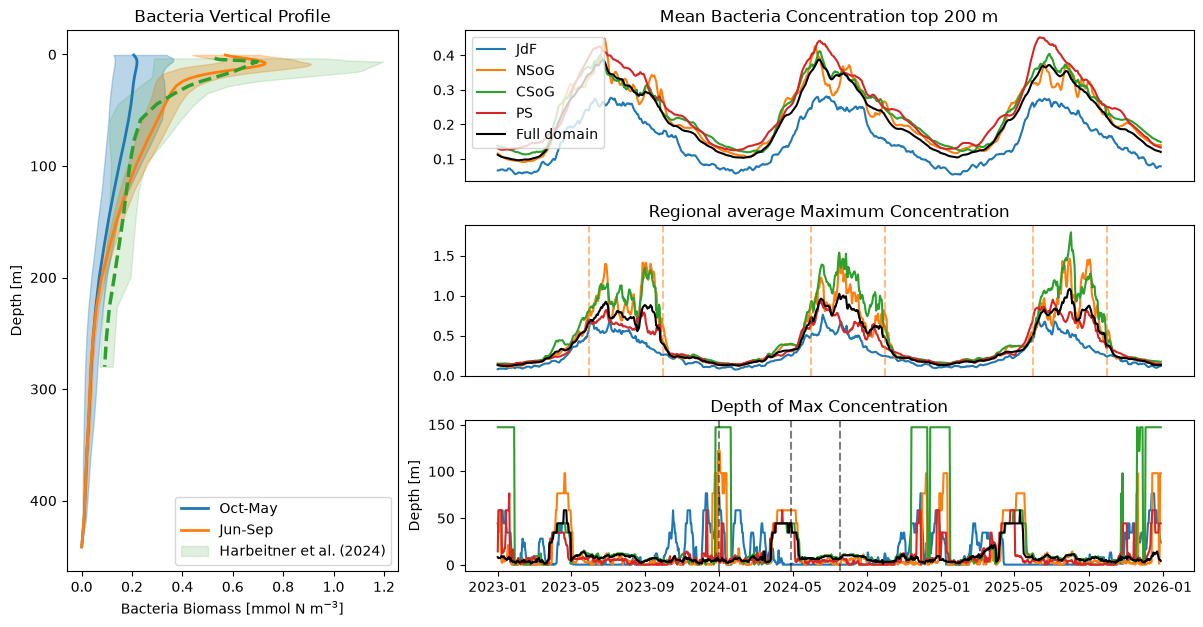

In [451]:
axes[3].clear()
axes[2].clear()

for ii, region in enumerate(regions.keys()):
    axes[3].plot(time,dtmr[ii,:].T,c=colors_reg[region],label=region)
axes[3].plot(time,dtm,c='k',label='Full domain')
axes[3].set_ylabel('Depth [m]')
axes[3].set_title('Depth of Max Concentration')
for ii, region in enumerate(regions.keys()):
    axes[2].plot(time,Dmaxr[ii,:].T,c=colors_reg[region],label=region)
axes[2].plot(time,Dmax,c='k',label='Full domain')

#axes[2].plot(time,diatmax,c='purple',label='Diatoms')
#axes[2].plot(time,ponmax,c='c',label='PON')
#axes[3].plot(time,pondep,c='c')

axes[2].set_title('Regional average Maximum Concentration')
#axes[2].set_ylabel('Concentration [mmol N/m3]')

axes[2].tick_params(bottom=False, labelbottom=False)


for i in range(len(up)):
    axes[3].axvline(time[up[i]], color='k', linestyle='--', alpha=0.5)
   
for i in range(len(summers)):
    axes[2].axvline(time[summers[i]], color='tab:orange', linestyle='--', alpha=0.5)

fig

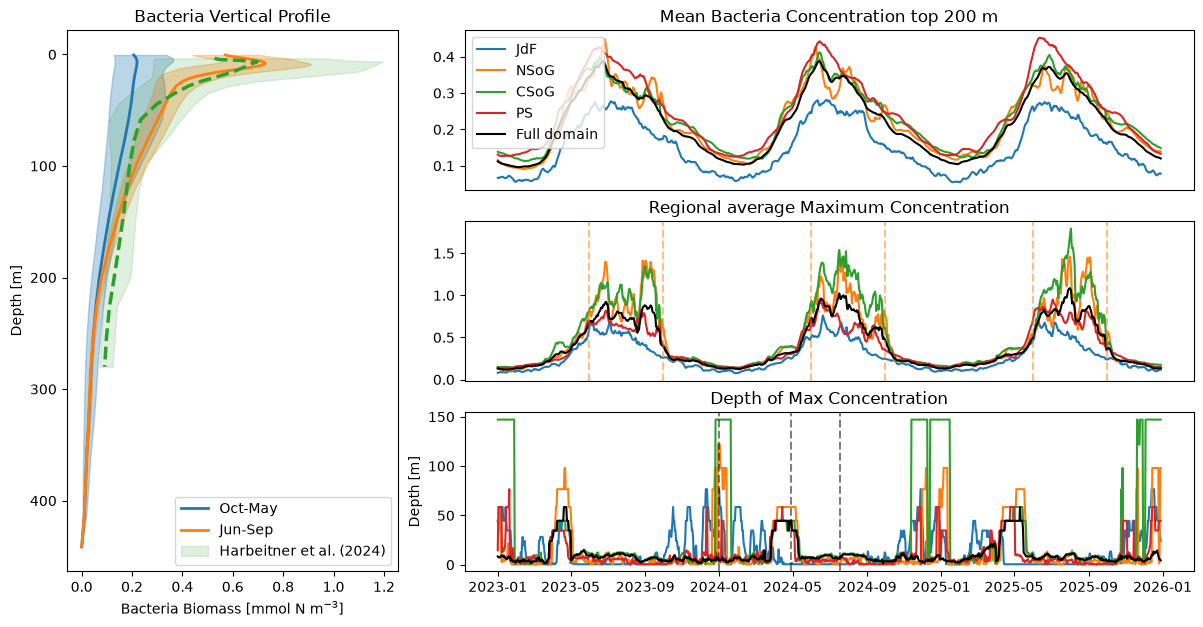

In [452]:
fig.subplots_adjust(hspace=0.2)
fig

In [453]:
axes[1].set_ylabel('')

pos_b = axes[1].get_position()
pos_c = axes[2].get_position()

fig.text(
    pos_b.x0 - 0.043,
    (pos_b.y1 + pos_c.y0) / 2,
    r'Bacteria biomass [mmol N m$^{-3}$]',
    rotation=90,
    va='center',
    ha='center'
)

Text(0.3276018518518519, 0.6744299396190767, 'Bacteria biomass [mmol N m$^{-3}$]')

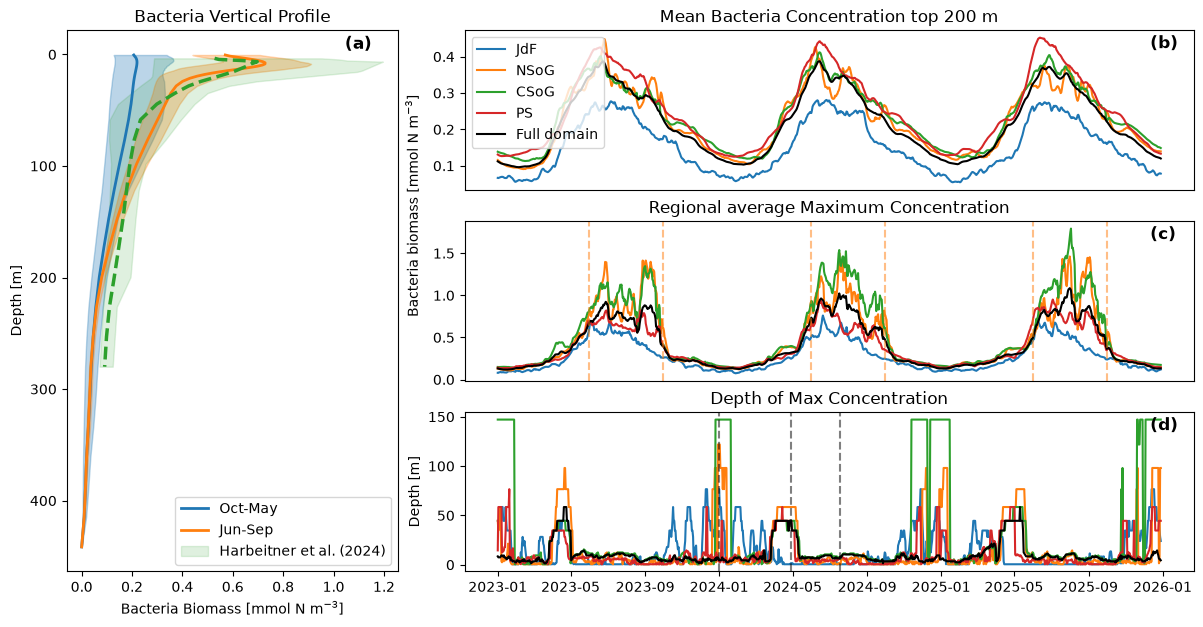

In [454]:
letters = ['(a)', '(b)', '(c)', '(d)']

axes[0].text(0.84, 0.99, letters[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1].text(0.94, 0.97, letters[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')
axes[2].text(0.94, 0.97, letters[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold', va='top')
axes[3].text(0.94, 0.97, letters[3], transform=axes[3].transAxes, fontsize=12, fontweight='bold', va='top')
fig

In [456]:
fig.savefig('Bacteria_timeseries.pdf',bbox_inches='tight')